# 07 · User study

**Question:** do real travellers find these questions useful when deciding on a hotel?

**Design**
- **5 amenities × 3 photos × 5 questions = 75 questions**, all from Gemini 3.0 Pro (general run).
- A pilot with 3 people set the size. More photos per amenity made the survey too long and hurt completion (125 questions was not realistic).
- Photos per amenity were picked by detection confidence: one from the **top 10%**, one from the **middle 50%**, and one **at random** from the rest. That puts clear and ambiguous detections in front of users, not just the easy ones. Each photo counted once (highest-confidence box kept), and photos scoring 0.25 or less were left out.
- Each question was rated 1 (not helpful at all) to 5 (extremely helpful): *"Imagine you are browsing hotels on trivago and see these pictures. How helpful would this question be?"*
- **37 participants**, recruited through university groups and forums, trivago forums, acquaintances and the general public. That gives **2,775 ratings**.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from amenity_qgen import config, plotting
from amenity_qgen.plotting import SERIES, MUTED, TEXT, TEXT_2

plotting.use_style()
pd.set_option("display.max_colwidth", 120)
FIG = ROOT / "results" / "figures"
AMENITIES = ["bathtub", "kettle", "hairdryer", "mirror", "tv"]
NAMES = {"bathtub": "Bathtub", "kettle": "Kettle", "hairdryer": "Hairdryer", "mirror": "Mirror", "tv": "TV"}

In [2]:
def select_study_images(df):
    """One high, one medium and one random photo per amenity."""
    df = df.loc[df.groupby("image")["score"].idxmax()]          # one detection per photo
    df = df[df["score"] > 0.25]                                   # drop weak detections
    top = df.nlargest(max(1, len(df) // 10), "score")             # high: top 10%
    high = top.sample(1).iloc[0]
    s = df.sort_values("score")
    mid = s.iloc[len(s) // 4: 3 * len(s) // 4]                   # medium: 25th-75th percentile
    medium = mid[mid.image != high.image].sample(1).iloc[0]
    rest = df[~df.image.isin([high.image, medium.image])]
    rand = rest.sample(1).iloc[0]
    return pd.DataFrame([high, medium, rand]).assign(tier=["high", "medium", "random"])

# the photos that were drawn for the survey
chosen = pd.DataFrame([
    ("bathtub", "high", "image_23", 0.610), ("bathtub", "medium", "image_146", 0.415), ("bathtub", "random", "image_181", 0.553),
    ("kettle", "high", "image_113", 0.411), ("kettle", "medium", "image_169", 0.349), ("kettle", "random", "image_53", 0.307),
    ("tv", "high", "image_205", 0.716), ("tv", "medium", "image_104", 0.375), ("tv", "random", "image_92", 0.492),
    ("hairdryer", "high", "image_3", 0.450), ("hairdryer", "medium", "image_76", 0.289), ("hairdryer", "random", "image_217", 0.297),
    ("mirror", "high", "image_62", 0.502), ("mirror", "medium", "image_160", 0.286), ("mirror", "random", "image_132", 0.330),
], columns=["amenity", "tier", "photo", "detection score"])
chosen.pivot(index="amenity", columns="tier", values="detection score").loc[AMENITIES].rename(index=NAMES)

tier,high,medium,random
amenity,,,
Bathtub,0.610,0.415,0.553
Kettle,0.411,0.349,0.307
Hairdryer,0.450,0.289,0.297
Mirror,0.502,0.286,0.330
TV,0.716,0.375,0.492


The 15 photos participants saw:

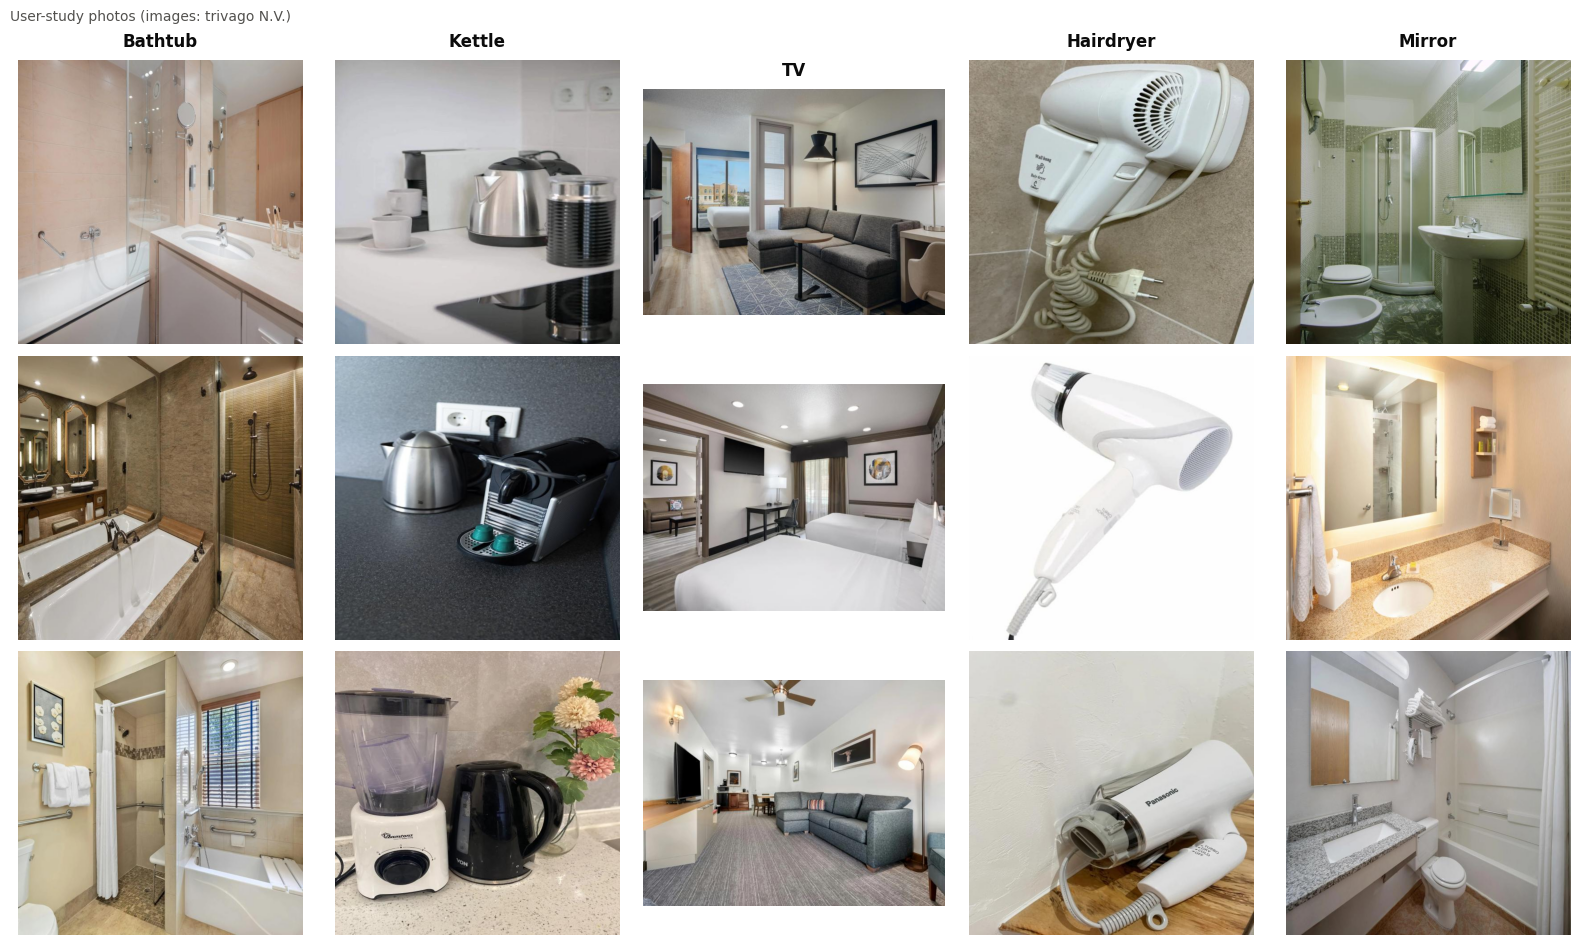

In [3]:
from PIL import Image
files = sorted((ROOT / "data" / "user_study_images").iterdir())
order = {"bathtub": 0, "kettle": 1, "tv": 2, "hairdryer": 3, "mirror": 4}
fig, axes = plt.subplots(3, 5, figsize=(16, 9.6))
for am, col in order.items():
    mine = [f for f in files if f.name.startswith(am + "_")]
    for r, f in enumerate(mine[:3]):
        ax = axes[r, col]; ax.imshow(Image.open(f)); ax.set_axis_off()
        if r == 0: ax.set_title(NAMES[am], loc="center")
fig.suptitle("User-study photos (images: trivago N.V.)", x=0.01, ha="left", color=TEXT_2, fontsize=10)
plt.tight_layout(); fig.savefig(FIG / "study_images.png", dpi=90); plt.show()

## Participants

In [4]:
people = pd.read_csv(ROOT / "results" / "user_study" / "participants.csv")
ratings = pd.read_csv(ROOT / "results" / "user_study" / "ratings.csv")
for col in ["age_range", "travel_frequency", "booked_online_2y", "photo_importance"]:
    display(people[col].value_counts(normalize=True).mul(100).round(1).rename("% of participants").to_frame())

,% of participants
age_range,
26-35,59.5
18-25,27.0
36-50,13.5


,% of participants
travel_frequency,
Occasionally (2-4 times per year),64.9
Rarely (0-1 times per year),18.9
Frequently (5-10 times per year),13.5
Very frequently (10+ times per year),2.7


,% of participants
booked_online_2y,
Yes,86.5
No,13.5


,% of participants
photo_importance,
Very important,32.4
Critical to my decision,27.0
Important,27.0
Somewhat important,13.5


## Usefulness by amenity

In [5]:
from amenity_qgen.study import amenity_summary, question_summary

amen = amenity_summary(ratings)
amen.to_csv(ROOT / "results" / "user_study" / "amenity_summary.csv", index=False)
print(f"Overall mean: {ratings.rating.mean():.2f} / 5 across {len(ratings):,} ratings")
print(f"Rated 4 or 5: {(ratings.rating >= 4).mean():.1%}")
amen.assign(amenity=amen.amenity.map(NAMES)).round(3)

Overall mean: 3.36 / 5 across 2,775 ratings
Rated 4 or 5: 49.6%


,amenity,mean,std,n,share_4_or_5
0,Bathtub,3.450,1.453,555,0.535
2,Kettle,3.450,1.413,555,0.517
1,Hairdryer,3.411,1.373,555,0.510
4,TV,3.274,1.414,555,0.450
3,Mirror,3.218,1.409,555,0.467


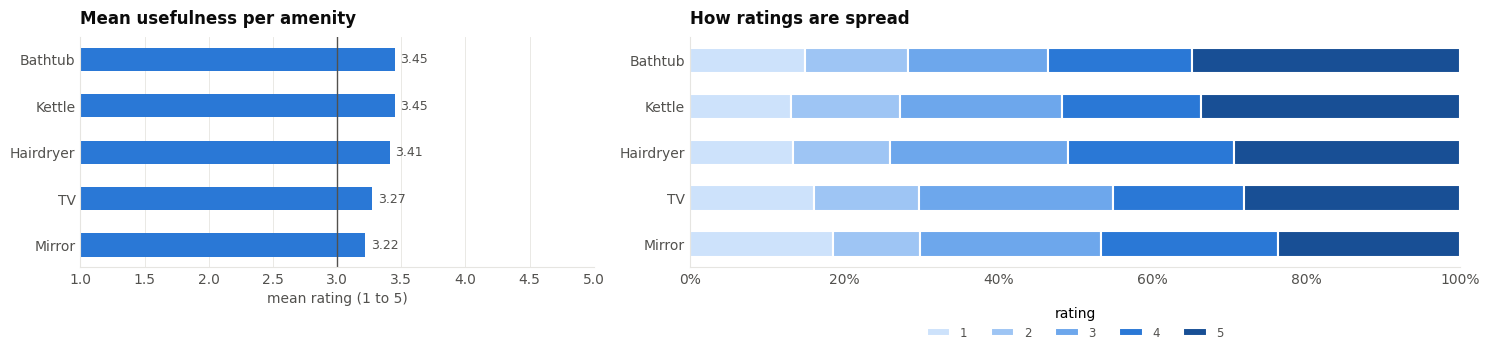

In [6]:
dist = (ratings.groupby("amenity").rating.value_counts(normalize=True).unstack().loc[amen.amenity[::-1]])
ramp = ["#cde2fb", "#9ec5f4", "#6da7ec", "#2a78d6", "#184f95"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 3.9), gridspec_kw={"width_ratios": [1, 1.5]})
bars = a1.barh([NAMES[a] for a in amen.amenity[::-1]], amen["mean"][::-1], color=SERIES[0], height=0.5)
for b in bars:
    a1.annotate(f"{b.get_width():.2f}", (b.get_width(), b.get_y() + b.get_height() / 2), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color=TEXT_2)
a1.axvline(3, color=TEXT_2, lw=1); a1.set_xlim(1, 5); a1.set_xlabel("mean rating (1 to 5)"); a1.grid(axis="y", visible=False)
a1.set_title("Mean usefulness per amenity")
left = np.zeros(len(dist))
for k, score in enumerate([1, 2, 3, 4, 5]):
    a2.barh([NAMES[a] for a in dist.index], dist[score], left=left, color=ramp[k], height=0.55, label=str(score), edgecolor="white", linewidth=1.5)
    left += dist[score].values
a2.set_xlim(0, 1); a2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}")); a2.grid(visible=False)
a2.set_title("How ratings are spread"); a2.legend(title="rating", ncol=5, fontsize=8.5, loc="lower center", bbox_to_anchor=(0.5, -0.36))
plt.tight_layout(); fig.savefig(FIG / "study_by_amenity.png"); plt.show()

Every amenity is above the neutral midpoint. Bathtub and kettle lead, because they are tied to how the stay actually feels. Mirror trails, since there is less about a mirror that changes a booking decision.

## Best and worst questions

In [7]:
qs = question_summary(ratings)
qs.to_csv(ROOT / "results" / "user_study" / "question_summary.csv", index=False)
cols = ["amenity", "question", "mean"]
print("Highest rated"); display(qs.nlargest(6, "mean")[cols].round(2))
print("Lowest rated"); display(qs.nsmallest(6, "mean")[cols].round(2))

Highest rated


,amenity,question,mean
34,kettle,"Does the appliance look modern and in good, clean condition?",4.08
61,tv,Does the TV have smart capabilities for streaming apps like Netflix or YouTube?,4.03
67,tv,Is this a Smart TV that allows guests to log into their own streaming accounts?,3.92
10,bathtub,Is there a separate walk-in shower in addition to the soaking tub?,3.86
38,kettle,Are there accessible power outlets immediately available at the beverage station?,3.81
31,kettle,Does it appear to be a full-sized kettle capable of boiling enough water for multiple cups?,3.78


Lowest rated


,amenity,question,mean
70,tv,"Is this a ""Frame"" style TV that displays artwork when not in use?",2.19
73,tv,Is the white border a digital display effect or a physical part of the frame?,2.22
8,bathtub,Do the bathroom tiles and fixtures appear modern or somewhat dated?,2.76
54,mirror,Does the backlit border design provide shadow-free illumination that is flattering for grooming?,2.78
47,mirror,"Since this appears to be a standard mirror, is a separate magnifying mirror provided for close-up grooming?",2.81
27,hairdryer,Does the dryer have a folding handle to save space on the bathroom counter?,2.84


The pattern is clear. The best questions are about things a guest can relate to their stay and that the photo supports: condition, smart-TV streaming, power sockets near the kettle, a separate shower. The worst need guesswork the photo cannot back up ("Frame" style TVs, whether a white border is part of the screen). **Visual grounding is what makes a question useful.**

## Would people want this feature?

In [8]:
useful = people.feature_useful.value_counts(normalize=True).reindex(["Not at all useful", "Slightly useful", "Moderately useful", "Extremely useful"]).mul(100)
display(useful.round(1).rename("% of participants").to_frame())
print(f"Moderately or extremely useful: {useful[['Moderately useful', 'Extremely useful']].sum():.1f}%")

vs = people.vs_descriptions.value_counts(normalize=True).sort_index().mul(100)
display(vs.round(1).rename("% rating AI questions vs typical descriptions (1 = much less useful, 5 = much more)").to_frame())
print(f"Rated 4 or 5: {vs.loc[[4, 5]].sum():.1f}%")

display(people.most_helpful_amenity.value_counts(normalize=True).mul(100).round(1).rename("% chose as most helpful").to_frame())

,% of participants
feature_useful,
Not at all useful,2.7
Slightly useful,29.7
Moderately useful,45.9
Extremely useful,21.6


Moderately or extremely useful: 67.6%


,"% rating AI questions vs typical descriptions (1 = much less useful, 5 = much more)"
vs_descriptions,
1,2.7
2,16.2
3,37.8
4,27.0
5,16.2


Rated 4 or 5: 43.2%


,% chose as most helpful
most_helpful_amenity,
Bathtub,37.8
TV,24.3
Hairdryer,16.2
Kettle,16.2
Mirror,5.4


## What participants wrote

In [9]:
for c in people.comment.dropna():
    print("-", c.strip())

- I think the questions could be designed based on some kind of user profiling. Someone traveling on business could find the detailed questions about the TV more useful and the kettle, maybe not so much. A couple might find the bathtub questions more relevant. Co-relating the AI questions based on the user and the booking type could deem to be useful.
- Like the idea! A lot
- It's quite difficult to determine the quality of these questions as some things are already evident from the photos.
- Never really given any attention to these things in detail, but if the AI generated questions are provided, depending on the type of trip, it can help solve a lot of problems in general.


## Takeaways
- **3.36 / 5 overall, and 49.6% of all ratings were 4 or 5.** Nearly half the questions were clearly useful to real travellers, straight from the model with no manual curation.
- **Two thirds (67.6%) would find a "smart question" feature moderately or extremely useful** on a booking site, and 43.2% rated the AI questions better than typical hotel descriptions.
- Usefulness depends on grounding. The next step is ranking or filtering questions by how well the photo supports them, which the rating spread shows is worth doing.
- The comments ask for profile-based questions, which notebook 05 covers.